In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

seed_val = 42
np.random.seed(seed_val)
torch.manual_seed(seed_val)

In [33]:
class AutoencoderDataset(Dataset):
    def __init__(self, data_tensor):
        self.data_tensor = data_tensor

    def __len__(self):
        return self.data_tensor.size(0)

    def __getitem__(self, idx):
        # For an autoencoder, X=Y (We need to reconstruct the input)
        x = self.data_tensor[idx]
        return x, x

In [34]:
# Charger les jeux d'entraînement et de test directement
train_df = pd.read_csv('../../../data/train_resample_standard_all.csv')
val_df = pd.read_csv('../../../data/test_resample_standard_all.csv')

# Print shapes
print("Train shape:", train_df.shape)
print("Test shape:", val_df.shape)

print(f"Total aggregate rows: {train_df.shape[0] + val_df.shape[0]}")


# Préparer tes données pour l'entraînement
data_id_train = train_df["apogee_id"]
data_target_train = train_df[["TEFF", "J", "H", "K", "LOGG"]]
train_data = train_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Préparer tes données pour la validation (test final)
data_id_val = val_df["apogee_id"]
data_target_val = val_df[["TEFF", "J", "H", "K", "LOGG"]]
val_data = val_df.drop(columns=["apogee_id", "TEFF", "J", "H", "K", "LOGG"]).astype('float32')

# Convertir en tenseurs PyTorch directement
train_tensor = torch.tensor(train_data.values, dtype=torch.float32)
val_tensor = torch.tensor(val_data.values, dtype=torch.float32)




# Créer les datasets PyTorch correspondants
train_dataset = AutoencoderDataset(train_tensor)
val_dataset = AutoencoderDataset(val_tensor)

# Créer les DataLoaders correspondants
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

# Optionnel : créer un tenseur global si nécessaire pour les visualisations plus tard :
full_data_tensor = torch.cat([train_tensor, val_tensor], dim=0)
data_id = pd.concat([data_id_train, data_id_val], ignore_index=True)





Train shape: (129124, 23)
Test shape: (32282, 23)
Total aggregate rows: 161406


In [35]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=20, latent_dim=2):
        super(Autoencoder, self).__init__()

        # Encoder : 20 -> 32 -> 64 -> 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),                # BatchNorm should improve training
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, latent_dim)          # No activation after 2D layer latent space
        )

        # Decoder : 2 -> 64 -> 32 -> 20
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(negative_slope=0.01),

            nn.Linear(32, input_dim)           # Output 20D vector
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device :", device)

model = Autoencoder(input_dim=17, latent_dim=2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using device : cuda


In [37]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create output directories for latent embeddings and model weights
output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)
weight_folder = "output_weight"
os.makedirs(weight_folder, exist_ok=True)

# Training hyperparameters
num_epochs = 100
patience = 5
criterion = nn.MSELoss()
best_val_loss = float('inf')
epochs_no_improve = 0

# Loop over desired latent dimensions
for latent_dim in [2, 3, 4]:
    print(f"\nTraining autoencoder with latent dimension: {latent_dim}")

    model = Autoencoder(input_dim=17, latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation loop
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, Y_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
            torch.save(model.state_dict(), model_file)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stop!")
                break

    # Load the best model weights
    model_file = os.path.join(weight_folder, f"best_autoencoder_{latent_dim}D.pth")
    model.load_state_dict(torch.load(model_file))
    model.eval()

    # Compute latent embeddings for the full dataset
    with torch.no_grad():
        # Ensure the full dataset is processed on the same device
        full_tensor_device = full_data_tensor.to(device)
        latent_embeddings = model.encoder(full_tensor_device)
    latent_embeddings = latent_embeddings.cpu().numpy()

    # Create a DataFrame for the latent embeddings
    df_latent = pd.DataFrame(latent_embeddings, columns=[f"latent_{i+1}" for i in range(latent_dim)])
    # Add the "apogee_id" column as the first column (assuming data_id is defined)
    df_latent.insert(0, "apogee_id", data_id)

    # Save the latent embeddings to a CSV file
    output_file = os.path.join(output_folder, f"autoencoder_latent_space_{latent_dim}D.csv")
    df_latent.to_csv(output_file, index=False)
    print(f"Latent space {latent_dim}D saved to {output_file}")

Using device: cuda

Training autoencoder with latent dimension: 2
Epoch [1/100]  Train Loss: 0.539757  |  Val Loss: 0.421350
Epoch [2/100]  Train Loss: 0.412397  |  Val Loss: 0.390554
Epoch [3/100]  Train Loss: 0.381682  |  Val Loss: 0.365037
Epoch [4/100]  Train Loss: 0.362868  |  Val Loss: 0.354525
Epoch [5/100]  Train Loss: 0.354101  |  Val Loss: 0.345693
Epoch [6/100]  Train Loss: 0.347860  |  Val Loss: 0.342034
Epoch [7/100]  Train Loss: 0.343518  |  Val Loss: 0.337314
Epoch [8/100]  Train Loss: 0.339103  |  Val Loss: 0.331961
Epoch [9/100]  Train Loss: 0.335715  |  Val Loss: 0.330735
Epoch [10/100]  Train Loss: 0.332230  |  Val Loss: 0.326553
Epoch [11/100]  Train Loss: 0.327837  |  Val Loss: 0.322899
Epoch [12/100]  Train Loss: 0.323946  |  Val Loss: 0.324724
Epoch [13/100]  Train Loss: 0.321548  |  Val Loss: 0.317788
Epoch [14/100]  Train Loss: 0.318110  |  Val Loss: 0.314147
Epoch [15/100]  Train Loss: 0.315753  |  Val Loss: 0.311372
Epoch [16/100]  Train Loss: 0.313911  |  Va

In [38]:

with torch.no_grad():
    val_data_gpu = val_tensor.to(device)
    latent_2d = model.encoder(val_data_gpu).cpu().numpy()

print("Latent space shape (Test set only):", latent_2d.shape)
print("Embedding sample:\n", latent_2d[:5])

Latent space shape (Test set only): (32282, 4)
Embedding sample:
 [[ 0.8867641   0.25012448 -0.9090384   1.3376839 ]
 [-1.2600554  -1.0374131  -0.8546721   0.76798284]
 [ 0.5357924  -0.93928593 -0.5039643   0.08368507]
 [ 0.14049211 -0.07668103 -0.13212574  0.18341935]
 [ 0.137424   -0.3398167  -0.07711331  0.51221585]]


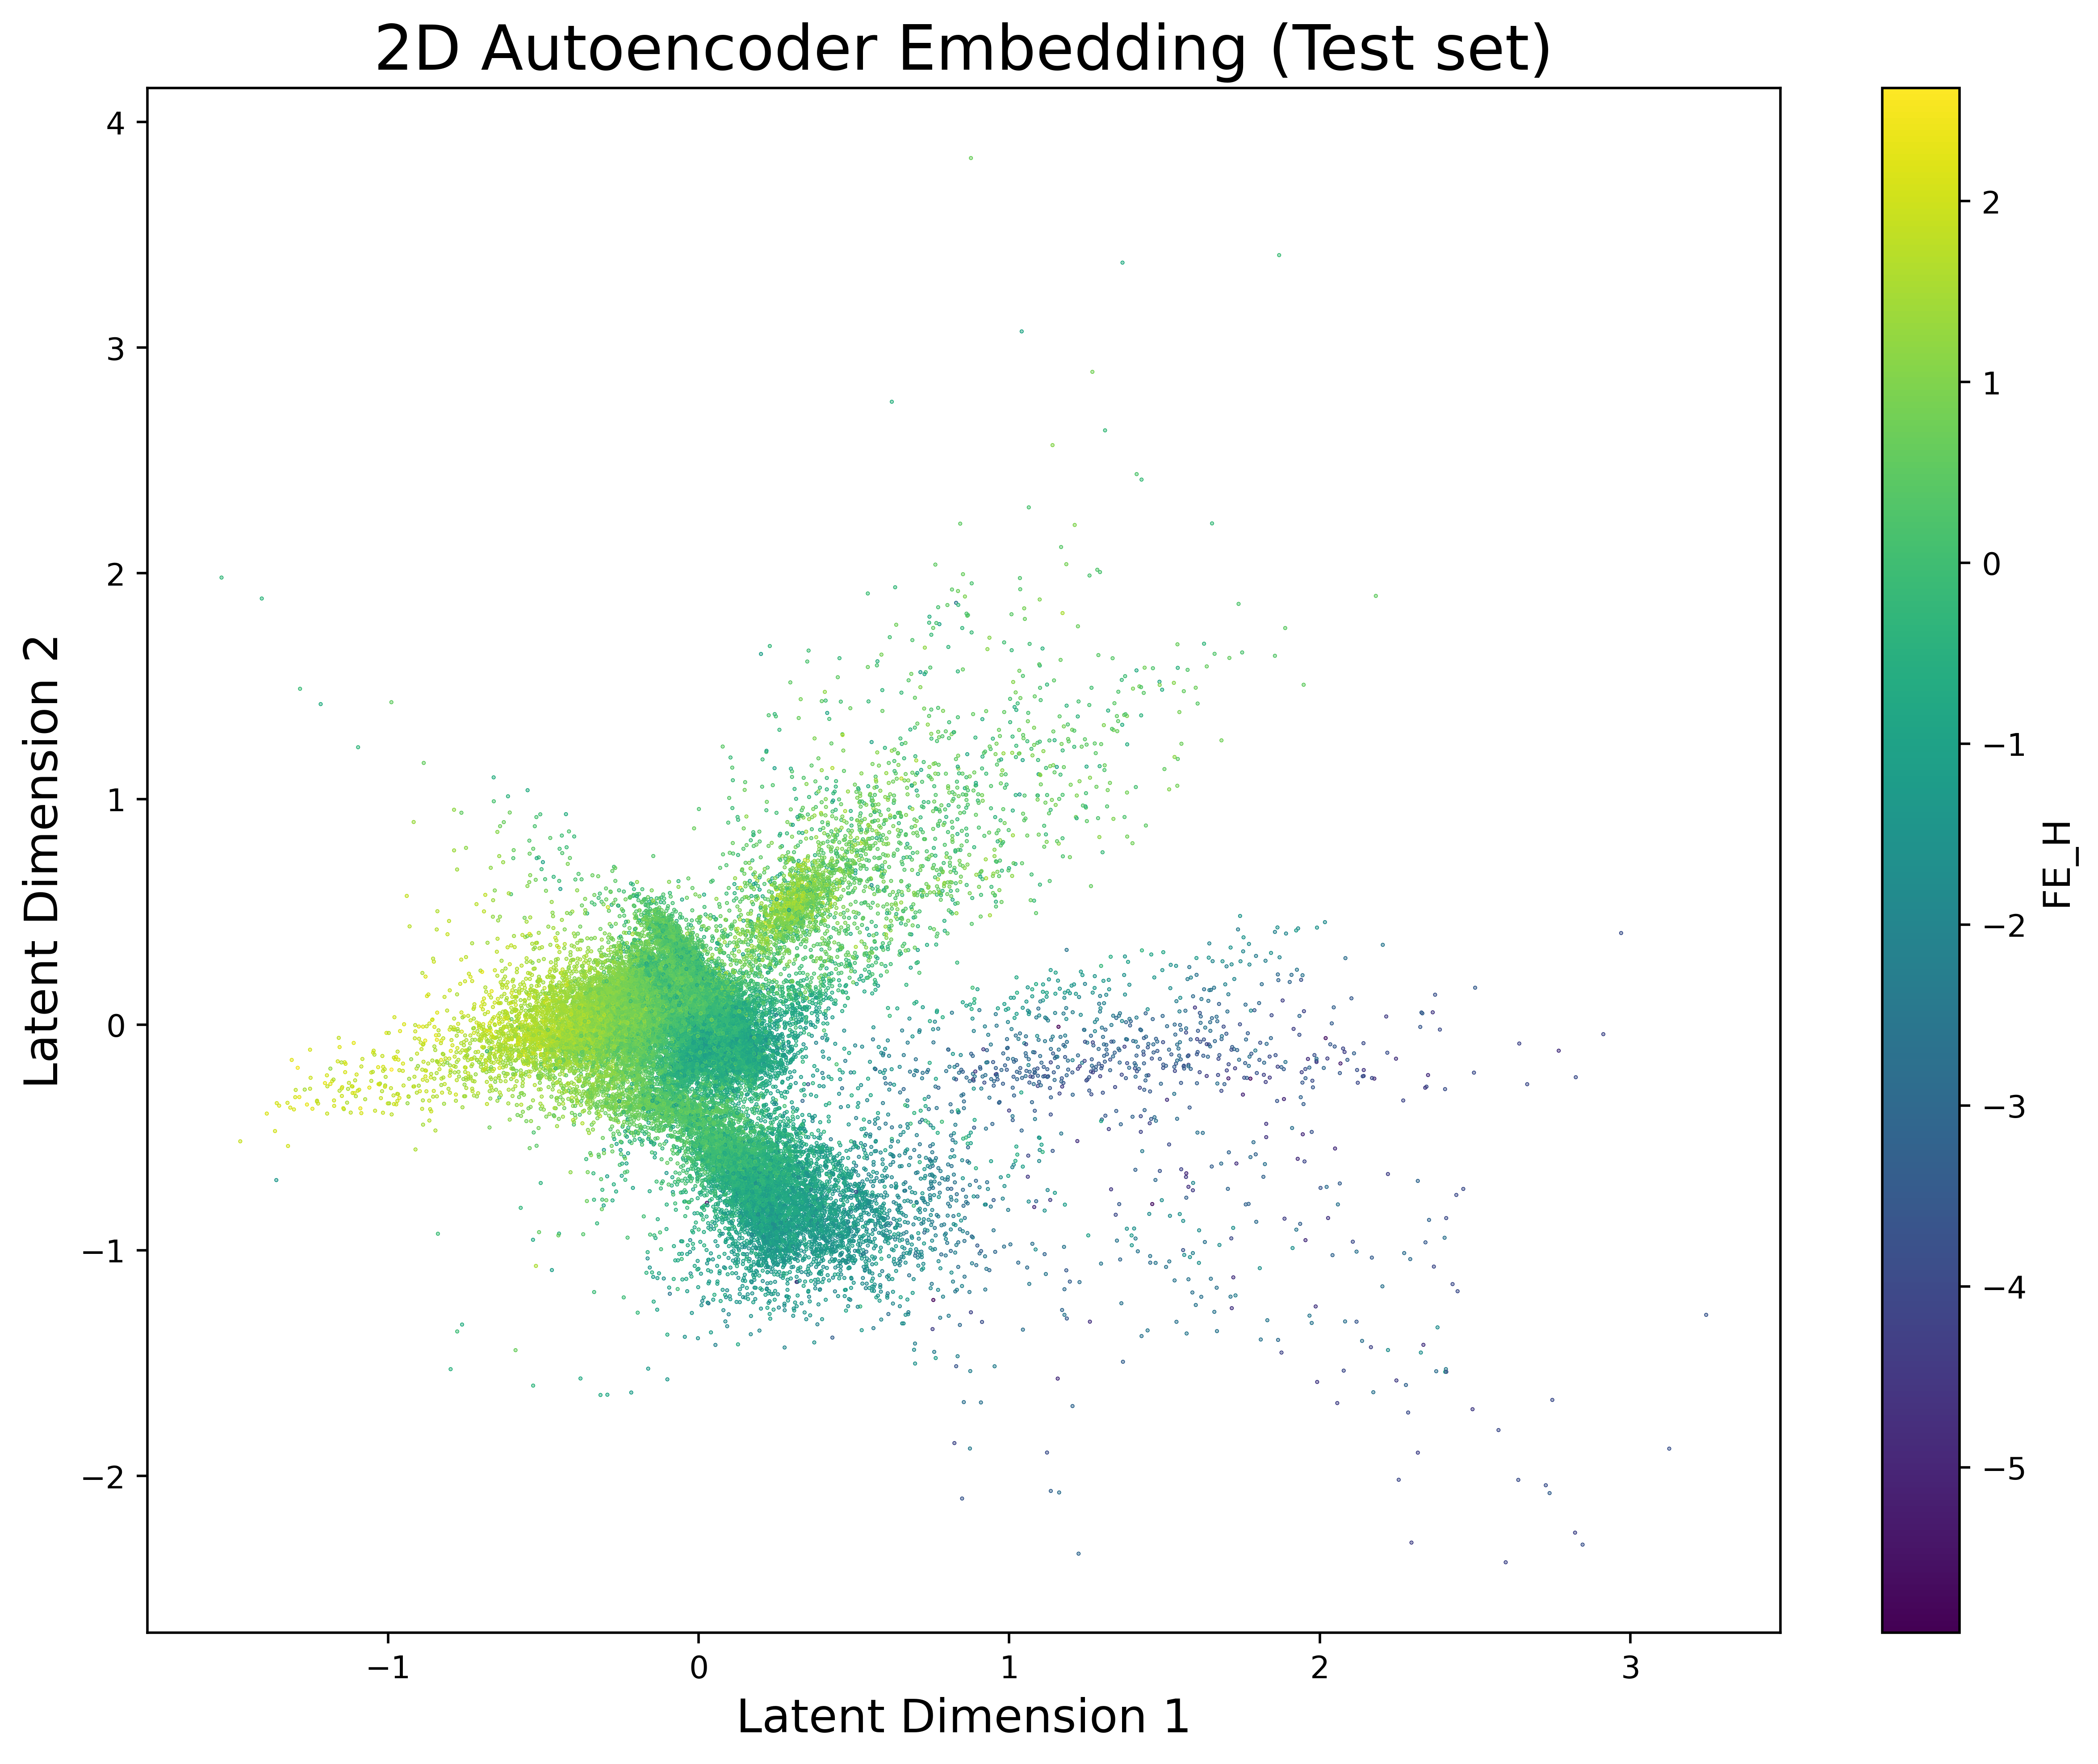

In [39]:
# Charger explicitement les embeddings depuis le CSV
data_to_plot = pd.read_csv("output_dataset/autoencoder_latent_space_2D.csv")


val_df_fe_h = val_df[['apogee_id', 'FE_H', 'TEFF']]
# get fe_h_values by merging with val_data
df_merged = pd.merge(data_to_plot, val_df_fe_h, on='apogee_id', how='inner')

# get latent_1 and latent_2 as numpy arrays
latent_1 = df_merged["latent_1"].values
latent_2 = df_merged["latent_2"].values
fe_h = df_merged["FE_H"].values

# Plot clair des embeddings avec FE_H comme couleur
fig = plt.figure(figsize=(10, 8), dpi=500)
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel('Latent Dimension 1', fontsize=15)
ax.set_ylabel('Latent Dimension 2', fontsize=15)
ax.set_title('2D Autoencoder Embedding (Test set)', fontsize=20)

scatter = ax.scatter(
    latent_1,
    latent_2,
    cmap='viridis',
    c=fe_h,
    s=0.1
)

cbar = plt.colorbar(scatter)
cbar.set_label('FE_H', fontsize=12)

plt.tight_layout()
plt.show()

Étoile choisie (Test set): apogee_id=2M01064163-0855466, row_index=1


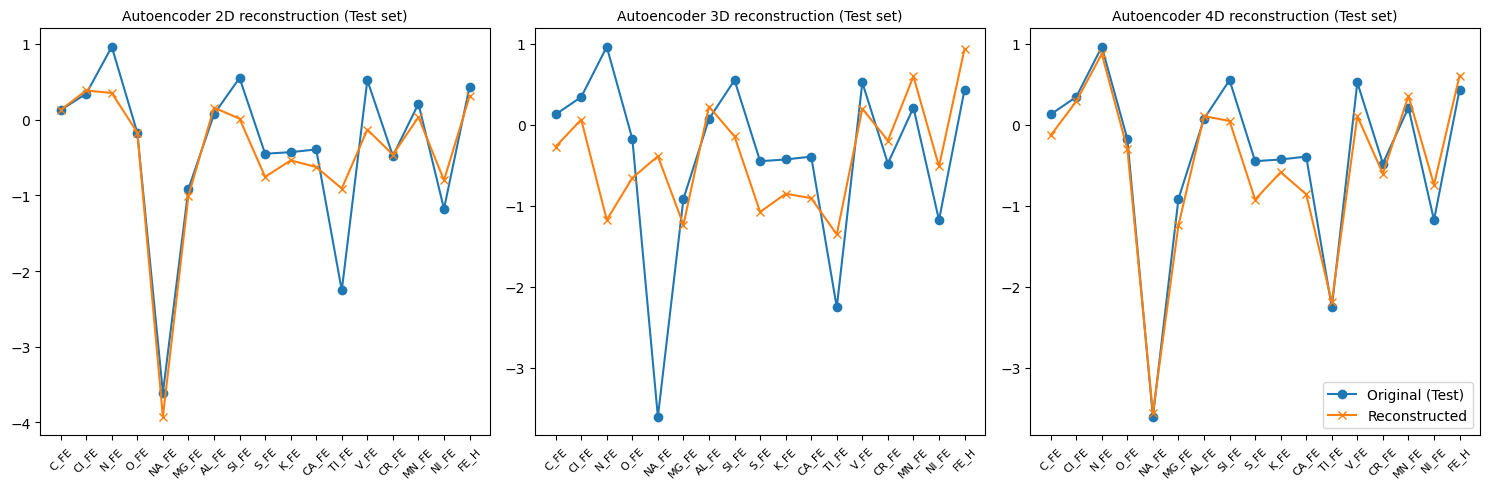

In [43]:
col_names = list(val_data.columns)  # uniquement colonnes numériques du test (sans apogee_id)

chosen_id = "2M01064163-0855466"
row_index = data_id_val[data_id_val == chosen_id].index
if len(row_index) == 0:
    raise ValueError(f"Impossible de trouver apogee_id='{chosen_id}' dans le jeu de TEST.")
row_index = row_index[0]
print(f"Étoile choisie (Test set): apogee_id={chosen_id}, row_index={row_index}")

original_abundance = val_data.iloc[row_index].values.astype(np.float32)  # corrigé ici : val_data au lieu de val_df

# Tenseur correspondant uniquement au jeu de test
x_star_tensor = val_tensor[row_index].unsqueeze(0).to(device)  # shape (1,17)

latent_dims = [2, 3, 4]
reconstructions = {}

for d in latent_dims:
    model = Autoencoder(input_dim=17, latent_dim=d).to(device)

    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Avertissement: Fichier de poids introuvable: {model_path} ***")
        continue

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        x_recon = model(x_star_tensor).cpu().numpy().flatten()

    reconstructions[d] = x_recon

fig, axes = plt.subplots(1, len(latent_dims), figsize=(5 * len(latent_dims), 5), dpi=100)

if len(latent_dims) == 1:
    axes = [axes]

for idx, d in enumerate(latent_dims):
    ax = axes[idx]
    if d not in reconstructions:
        ax.text(0.5, 0.5, f"{d}D\nNo model", ha='center', va='center', transform=ax.transAxes)
        ax.axis("off")
        continue

    recon = reconstructions[d]
    x = np.arange(len(col_names))

    ax.plot(x, original_abundance, marker='o', label="Original (Test)")
    ax.plot(x, recon, marker='x', label="Reconstructed")

    ax.set_xticks(x)
    ax.set_xticklabels(col_names, rotation=45, fontsize=8)
    ax.set_title(f"Autoencoder {d}D reconstruction (Test set)", fontsize=10)

    if idx == len(latent_dims) - 1:
        ax.legend()

plt.tight_layout()
plt.show()


Taille du jeu de TEST: (32282, 17), variance totale=16.8661
[2D] MSE=0.292890, Var_expl=0.982634
[3D] MSE=0.228650, Var_expl=0.986443
[4D] MSE=0.178108, Var_expl=0.989440


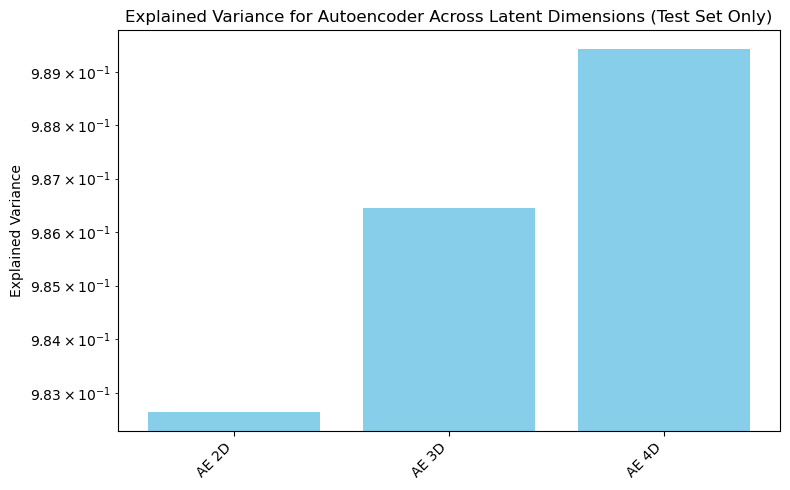

In [44]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# Récupération explicite du jeu TEST
# ---------------------------
val_X_tensor = val_tensor  # (N_test, 17)
val_X_np = val_X_tensor.cpu().numpy()

# Calcul explicite de la variance totale sur le TEST uniquement
cov_matrix = np.cov(val_X_np, rowvar=False)
total_variance = np.trace(cov_matrix)

print(f"Taille du jeu de TEST: {val_X_np.shape}, variance totale={total_variance:.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_folder = "output_weight"
latent_dims = [2, 3, 4]

explained_variances_ae = {}

val_X_tensor = val_X_tensor.to(device)

for d in latent_dims:
    model_path = os.path.join(weight_folder, f"best_autoencoder_{d}D.pth")
    if not os.path.isfile(model_path):
        print(f"*** Pas de fichier de poids trouvé pour {d}D: {model_path} ***")
        continue

    # Charger le modèle Autoencoder exactement comme entraîné
    model = Autoencoder(input_dim=17, latent_dim=d).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Reconstruction explicite du jeu TEST
    with torch.no_grad():
        x_recon_tensor = model(val_X_tensor)

    x_recon_np = x_recon_tensor.cpu().numpy()

    # Calcul explicite du MSE global sur TEST
    mse_global = np.mean((x_recon_np - val_X_np)**2)

    # Calcul de la variance expliquée sur TEST
    explained_variance = 1.0 - (mse_global / total_variance)
    explained_variances_ae[d] = explained_variance

    print(f"[{d}D] MSE={mse_global:.6f}, Var_expl={explained_variance:.6f}")

# ---------------------------
# Diagramme en barres clair de la variance expliquée sur TEST
# ---------------------------
labels = [f"AE {d}D" for d in latent_dims if d in explained_variances_ae]
ev_values = [explained_variances_ae[d] for d in latent_dims if d in explained_variances_ae]

plt.figure(figsize=(8, 5))
plt.bar(range(len(labels)), ev_values, color='skyblue')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Explained Variance")
plt.yscale("log")  # Échelle logarithmique pour une meilleure lisibilité
plt.title("Explained Variance for Autoencoder Across Latent Dimensions (Test Set Only)")
plt.tight_layout()
plt.show()
